# Retail Sales Analysis Dashboard
### End-to-End Data Analytics & Sales Forecasting Project
---
#### Project Overview & Business Case
A retail store wants to improve its profitability and understand its performance over the last two years (2024-2025). The business faces several challenges: raw sales data contains duplicate orders, missing details, inconsistent categories/regions, and format errors. 

This project outlines an end-to-end workflow to clean the raw records, conduct Exploratory Data Analysis (EDA) to extract business insights, create high-quality visualizations for stakeholders, and implement a machine learning regression model to project future sales trends.

#### Key Requirements Covered:
1. **Data Cleaning**: Handle missing values, drop duplicates, convert types, and standardize string columns.
2. **Exploratory Data Analysis (EDA)**: Monthly sales, profit margins, regional performance, top products, loss areas, and customer segmentation.
3. **Visualizations**: High-quality Seaborn and Matplotlib charts saved directly as portfolio assets.
4. **Predictive Modeling**: Simple Linear Regression forecasting to project monthly sales trends 6 months out.
5. **Business Insights**: Actionable business recommendations based on findings.


## Setup & Libraries Import
First, we import the core data science libraries: Pandas and NumPy for data manipulation, Matplotlib and Seaborn for charting, and Scikit-Learn for our regression model.


In [1]:
# Import data science stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import os

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10


## Load the Dataset
We load the raw dataset `retail_sales_data.csv` from the `data/raw/` folder and inspect its shape and top rows.


In [2]:
# Define path to raw dataset
raw_data_path = os.path.join("..", "data", "raw", "retail_sales_data.csv")

# Load data using pandas
df = pd.read_csv(raw_data_path)

# Inspect first 5 rows
df.head()


,Order ID,Order Date,Product Category,Product Name,Region,Sales,Profit,Quantity,Customer Segment
0,CA-2024-101189,2024-09-07,Office Supplies,Heavy Duty 3-Ring Binder,North,52.83,8.18,4.0,Home Office
1,CA-2024-100760,2024-06-22,Office Supplies,Stainless Steel Scissors,west,37.34,9.58,5.0,Consumer
2,CA-2025-100121,2024-04-26,Office Supplies,Gel Pens (12-pack),West,89.66,20.46,8.0,Home Office
3,CA-2024-100535,2024-08-20,FURNITURE,Adjustable Side Table,East,81.68,-1.45,1.0,Home Office
4,CA-2024-101096,30-03-2025,FURNITURE,Leather Executive Sofa,West,8740.92,917.59,8.0,consumer


### Initial Inspection of Structure & Data Types
Before performing any cleanups, let's understand the data columns, data types, and check for missing values.


In [3]:
# Get shape of dataset
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Get information on column data types and non-null values
df.info()


Dataset contains 1220 rows and 9 columns.

<class 'pandas.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          1220 non-null   str    
 1   Order Date        1213 non-null   str    
 2   Product Category  1220 non-null   str    
 3   Product Name      1206 non-null   str    
 4   Region            1220 non-null   str    
 5   Sales             1203 non-null   float64
 6   Profit            1204 non-null   float64
 7   Quantity          1204 non-null   float64
 8   Customer Segment  1211 non-null   str    
dtypes: float64(3), str(6)
memory usage: 85.9 KB


### Statistical Summary of Numeric Columns
Let's look at the summary statistics. Note that numeric columns loaded as strings due to missing values or anomalies won't appear here yet.


In [4]:
# Generate descriptive statistics
df.describe(include='all')


,Order ID,Order Date,Product Category,Product Name,Region,Sales,Profit,Quantity,Customer Segment
count,1220,1213,1220,1206,1220,1203.000000,1204.000000,1204.000000,1211
unique,1200,629,11,18,7,NaN,NaN,NaN,6
top,CA-2025-100402,2024-01-13,Technology,Stainless Steel Scissors,South,NaN,NaN,NaN,Home Office
freq,2,6,246,76,302,NaN,NaN,NaN,295
mean,NaN,NaN,NaN,NaN,NaN,1415.896617,236.180731,4.389535,NaN
std,NaN,NaN,NaN,NaN,NaN,2197.593261,474.737185,2.360014,NaN
min,NaN,NaN,NaN,NaN,NaN,6.270000,-97.040000,-1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,79.280000,9.267500,2.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,458.520000,29.860000,4.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,1602.295000,190.275000,6.000000,NaN


## 🛠️ Data Cleaning
Our initial inspection reveals several issues: missing cells, duplicate rows, incorrect date formatting, inconsistent category/region names (spaces, casing), and invalid negative numbers for Quantity.

Let's clean these step-by-step to prepare the dataset for analysis.


### Step 1: Handling Missing Values
Let's inspect how many null values exist in each column.


In [5]:
# Count missing values per column
print("Missing values before cleaning:")
print(df.isnull().sum())

# 1. Fill missing Product Names with 'Unknown Product'
df['Product Name'] = df['Product Name'].fillna('Unknown Product')

# 2. Fill missing Customer Segment with the mode (most common segment)
segment_mode = df['Customer Segment'].mode()[0]
df['Customer Segment'] = df['Customer Segment'].fillna(segment_mode)

# 3. For numeric values (Sales, Profit, Quantity), we impute them with the median of their respective Product Category.
# This ensures we do not bias the sales values with general medians across very different priced items.
df['Sales'] = df.groupby('Product Category')['Sales'].transform(lambda x: x.fillna(x.median()))
df['Profit'] = df.groupby('Product Category')['Profit'].transform(lambda x: x.fillna(x.median()))
df['Quantity'] = df.groupby('Product Category')['Quantity'].transform(lambda x: x.fillna(x.median()))

# Let's check missing values again
print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values before cleaning:
Order ID             0
Order Date           7
Product Category     0
Product Name        14
Region               0
Sales               17
Profit              16
Quantity            16
Customer Segment     9
dtype: int64

Missing values after imputation:
Order ID            0
Order Date          7
Product Category    0
Product Name        0
Region              0
Sales               0
Profit              0
Quantity            0
Customer Segment    0
dtype: int64


### Step 2: Removing Duplicate Records
Duplicate records can skew our totals. We find and remove duplicates, keeping the first occurrence.


In [6]:
# Check for exact duplicate rows
duplicates = df.duplicated().sum()
print(f"Found {duplicates} duplicate rows in the dataset.")

# Drop duplicates
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Successfully removed duplicates. New dataset shape: {df.shape}")


Found 20 duplicate rows in the dataset.
Successfully removed duplicates. New dataset shape: (1200, 9)


### Step 3: Date Standardization
We convert the `Order Date` column to datetime objects. We use `errors='coerce'` to flag invalid dates (like 'N/A') as `NaT` (Not a Time), which we can then drop.


In [7]:
# Convert Date column to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Identify and drop rows with invalid date formats (NaT)
nat_count = df['Order Date'].isna().sum()
print(f"Found {nat_count} rows with unparseable or missing dates.")

if nat_count > 0:
    df = df.dropna(subset=['Order Date']).reset_index(drop=True)
    print(f"Dropped invalid date rows. New shape: {df.shape}")

# Sort dataframe chronologically by Order Date for better time series alignment
df = df.sort_values(by='Order Date').reset_index(drop=True)
df['Order Date'].head()


Found 46 rows with unparseable or missing dates.
Dropped invalid date rows. New shape: (1154, 9)


0   2024-01-01
1   2024-01-02
2   2024-01-03
3   2024-01-03
4   2024-01-03
Name: Order Date, dtype: datetime64[us]

### Step 4: Standardizing Text Columns
Categorical columns (`Product Category`, `Region`, `Customer Segment`) contain trailing spaces and inconsistent letter casing (e.g. 'tech', 'Technology', 'FURNITURE'). We will clean and standardize these.


In [8]:
# Display unique values before cleaning to identify anomalies
print("Product Categories (before):", df['Product Category'].unique())
print("Regions (before):           ", df['Region'].unique())
print("Customer Segments (before): ", df['Customer Segment'].unique())

# Clean and standardize Product Category
df['Product Category'] = df['Product Category'].astype(str).str.strip().str.title()
# Map abbreviations/aliases like 'Tech' to 'Technology'
df['Product Category'] = df['Product Category'].replace({'Tech': 'Technology'})

# Clean and standardize Region
df['Region'] = df['Region'].astype(str).str.strip().str.title()

# Clean and standardize Customer Segment
df['Customer Segment'] = df['Customer Segment'].astype(str).str.strip().str.title()

print("\n--- Standardized Categories ---")
print("Product Categories (after): ", df['Product Category'].unique())
print("Regions (after):            ", df['Region'].unique())
print("Customer Segments (after):  ", df['Customer Segment'].unique())


Product Categories (before): <StringArray>
[      'Furniture ',      'Technology ',             'tech',
       'Technology',        'Furniture',  'OFFICE SUPPLIES',
        'furniture',  'Office Supplies',        'FURNITURE',
 'Office Supplies ', 'office supplies ']
Length: 11, dtype: str
Regions (before):            <StringArray>
['North ', 'East', 'South', 'North', 'West', 'East ', 'west']
Length: 7, dtype: str
Customer Segments (before):  <StringArray>
['Home Office', 'Consumer', 'Corporate ', 'consumer', 'home office',
 'Corporate']
Length: 6, dtype: str

--- Standardized Categories ---
Product Categories (after):  <StringArray>
['Furniture', 'Technology', 'Office Supplies']
Length: 3, dtype: str
Regions (after):             <StringArray>
['North', 'East', 'South', 'West']
Length: 4, dtype: str
Customer Segments (after):   <StringArray>
['Home Office', 'Consumer', 'Corporate']
Length: 3, dtype: str


### Step 5: Handling Inconsistent Values & Type Casting
Quantity columns must be positive integers. In case of invalid inputs (like quantities ≤ 0 or float values), we filter and cast them appropriately.


In [9]:
# Check values of quantity
invalid_qty = (df['Quantity'] <= 0).sum()
print(f"Rows with invalid quantities (<= 0): {invalid_qty}")

# Keep only rows with positive quantity
if invalid_qty > 0:
    df = df[df['Quantity'] > 0].reset_index(drop=True)
    print(f"Filtered out invalid quantities. New dataset shape: {df.shape}")

# Cast Quantity to integer
df['Quantity'] = df['Quantity'].astype(int)
# Ensure Sales and Profit columns are float type
df['Sales'] = df['Sales'].astype(float)
df['Profit'] = df['Profit'].astype(float)

print("\nDatatypes and numeric ranges check:")
print(df[['Sales', 'Profit', 'Quantity']].describe())


Rows with invalid quantities (<= 0): 18
Filtered out invalid quantities. New dataset shape: (1136, 9)

Datatypes and numeric ranges check:
              Sales       Profit     Quantity
count   1136.000000  1136.000000  1136.000000
mean    1433.517051   235.769494     4.441901
std     2209.287865   479.354953     2.287327
min        6.270000   -97.040000     1.000000
25%       80.015000     9.397500     2.000000
50%      478.975000    28.940000     4.000000
75%     1606.075000   185.872500     6.000000
max    13596.580000  3413.800000     8.000000


### Step 6: Export Cleaned Dataset
We save our clean dataset to the `data/processed/` directory. This is standard data science practice to separate raw and clean state.


In [10]:
# Save clean dataset
processed_path = os.path.join("..", "data", "processed", "cleaned_sales_data.csv")
df.to_csv(processed_path, index=False)
print(f"Cleaned data successfully saved to: {processed_path}")


Cleaned data successfully saved to: ..\data\processed\cleaned_sales_data.csv


## 🔍 Exploratory Data Analysis (EDA)
Now that the dataset is verified clean and structured, we perform EDA to answer specific business questions and uncover growth opportunities.

We'll start by adding date features (Year, Month, Year-Month) to help with time-based calculations.


In [11]:
# Extract helper datetime features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M')
df['YearMonth_Str'] = df['YearMonth'].astype(str) # String format for plotting
df.head(3)


,Order ID,Order Date,Product Category,Product Name,Region,Sales,Profit,Quantity,Customer Segment,Year,Month,YearMonth,YearMonth_Str
0,CA-2025-100771,2024-01-01,Furniture,Adjustable Side Table,North,221.81,-3.90,3,Home Office,2024,1,2024-01,2024-01
1,CA-2024-100267,2024-01-02,Technology,Dell XPS 13 Laptop,East,6906.49,1640.53,7,Consumer,2024,1,2024-01,2024-01
2,CA-2025-100474,2024-01-03,Technology,Dell XPS 13 Laptop,South,5871.19,1621.62,6,Consumer,2024,1,2024-01,2024-01


### 1. Monthly Sales & Profit Trends
We group orders by month to analyze sales volume and profitability trends over the two-year period.


In [12]:
# Aggregate Sales and Profit by Month
monthly_summary = df.groupby('YearMonth_Str').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count'
}).rename(columns={'Order ID': 'Order Count'}).reset_index()

print("Monthly sales overview (First 6 months):")
monthly_summary.head(6)


Monthly sales overview (First 6 months):


,YearMonth_Str,Sales,Profit,Order Count
0,2024-01,100088.81,19398.690,57
1,2024-02,46000.04,8332.545,43
2,2024-03,63981.09,11877.090,50
3,2024-04,42657.18,5847.415,46
4,2024-05,54599.92,10372.650,54
5,2024-06,48755.52,6173.500,34


### 2. Regional Sales & Profit Performance
Let's see which geographical regions drive the most revenue and profits for the retail store.


In [13]:
# Aggregate Sales and Profit by Region
region_summary = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index().sort_values(by='Profit', ascending=False)

# Add Profit Margin percentage
region_summary['Profit Margin %'] = (region_summary['Profit'] / region_summary['Sales']) * 100

print("Performance by Region:")
region_summary


Performance by Region:


,Region,Sales,Profit,Quantity,Profit Margin %
0,East,465207.235,83553.535,1277,17.960498
2,South,366360.465,65370.490,1178,17.843216
3,West,404320.130,64824.625,1322,16.032995
1,North,392587.540,54085.495,1269,13.776671


### 3. Top-selling Categories
We investigate sales across product categories (Technology, Office Supplies, and Furniture).


In [14]:
# Aggregate sales by Category
category_summary = df.groupby('Product Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index().sort_values(by='Sales', ascending=False)

# Calculate category profit margin
category_summary['Profit Margin %'] = (category_summary['Profit'] / category_summary['Sales']) * 100

print("Category performance summary:")
category_summary


Category performance summary:


,Product Category,Sales,Profit,Quantity,Profit Margin %
2,Technology,913002.720,224287.980,1612,24.565971
0,Furniture,690232.925,38448.590,1724,5.570379
1,Office Supplies,25239.725,5097.575,1710,20.196634


### 4. Most Profitable Products
Identifying which specific products are generating the highest profit for the business.


In [15]:
# Aggregate sales and profit by Product Name
product_summary = df.groupby(['Product Name', 'Product Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

# Top 10 most profitable products
top_profitable_products = product_summary.sort_values(by='Profit', ascending=False).head(10)
print("Top 10 Most Profitable Products:")
top_profitable_products


Top 10 Most Profitable Products:


,Product Name,Product Category,Sales,Profit,Quantity
4,Dell XPS 13 Laptop,Technology,323853.36,79155.92,260
8,HP EliteBook Laptop,Technology,299570.90,65947.17,276
3,Apple iPad Air,Technology,185157.86,51726.20,247
10,Leather Executive Sofa,Furniture,312303.59,30096.20,286
11,Logitech MX Master 3 Mouse,Technology,40532.29,13905.01,303
13,Netgear Wireless Router,Technology,46089.85,9252.81,284
6,Ergonomic Office Chair,Furniture,95697.86,4731.63,294
15,Solid Wood Coffee Table,Furniture,57747.27,4619.61,234
2,Anker USB-C Hub,Technology,13906.41,3425.64,235
17,Standing Desk,Furniture,122882.50,2542.39,240


### 5. Loss-making Products and Sub-categories
Identifying products that have negative profit (bleeding cash) to advise stakeholders on pricing or catalog changes.


In [16]:
# Filter products with negative profit
loss_making_products = product_summary[product_summary['Profit'] < 0].sort_values(by='Profit')
print(f"Total unique products generating losses: {len(loss_making_products)}")
print("\nTop 5 Loss-making Products (Lowest profit first):")
loss_making_products.head(5)


Total unique products generating losses: 2

Top 5 Loss-making Products (Lowest profit first):


,Product Name,Product Category,Sales,Profit,Quantity
0,5-Shelf Bookshelf,Furniture,60971.310,-2937.96,326
1,Adjustable Side Table,Furniture,35011.505,-676.52,320


### 6. Customer Segment Analysis
Analyzing consumer, corporate, and home office purchasing patterns.


In [17]:
# Aggregate performance by customer segment
segment_summary = df.groupby('Customer Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index().sort_values(by='Sales', ascending=False)

segment_summary['Profit Margin %'] = (segment_summary['Profit'] / segment_summary['Sales']) * 100
print("Customer Segment Analysis:")
segment_summary


Customer Segment Analysis:


,Customer Segment,Sales,Profit,Quantity,Profit Margin %
2,Home Office,566442.635,93556.415,1860,16.516485
0,Consumer,559786.985,92263.160,1664,16.481834
1,Corporate,502245.750,82014.570,1522,16.329570


## 📊 Visualizations
To present our findings to stakeholders, we construct high-quality visuals. In this section, we save these plots directly to the `../images/` directory.


### Visualization 1: Monthly Sales and Profit Trends
A dual-line chart tracing sales volume and net profits across the 24-month horizon. This highlights seasonal trends and growth rates.


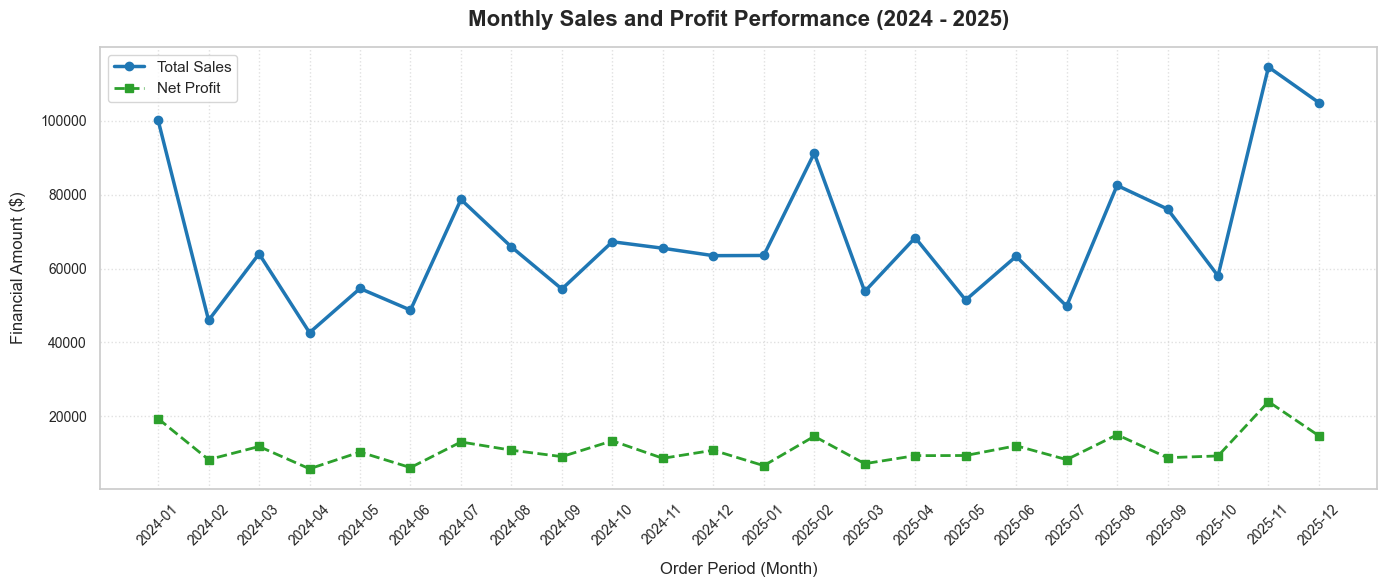

In [18]:
plt.figure(figsize=(14, 6))

# Plot Sales and Profit lines
plt.plot(monthly_summary['YearMonth_Str'], monthly_summary['Sales'], marker='o', color='#1f77b4', linewidth=2.5, label='Total Sales')
plt.plot(monthly_summary['YearMonth_Str'], monthly_summary['Profit'], marker='s', color='#2ca02c', linewidth=2.0, linestyle='--', label='Net Profit')

# Title and Label Formatting
plt.title('Monthly Sales and Profit Performance (2024 - 2025)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Order Period (Month)', fontsize=12, labelpad=10)
plt.ylabel('Financial Amount ($)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

# Save the chart
images_dir = os.path.join("..", "images")
os.makedirs(images_dir, exist_ok=True)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, "monthly_sales_trend.png"), dpi=300)
plt.show()


### Visualization 2: Product Category Sales & Profit Margin
A combination chart featuring sales as bars (left y-axis) and profit margin percentage as a line (right y-axis). This reveals high-volume vs. high-efficiency categories.


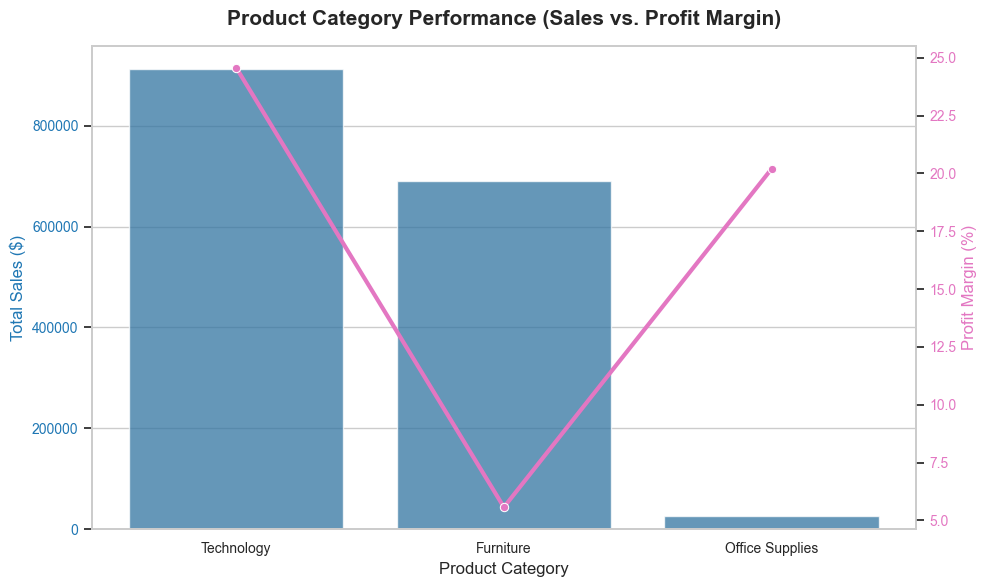

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Sales on primary axis
sns.barplot(data=category_summary, x='Product Category', y='Sales', color='#1f77b4', alpha=0.75, ax=ax1)
ax1.set_title('Product Category Performance (Sales vs. Profit Margin)', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Total Sales ($)', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xlabel('Product Category', fontsize=12)

# Double-axis line plot for profit margin
ax2 = ax1.twinx()
sns.lineplot(data=category_summary, x='Product Category', y='Profit Margin %', color='#e377c2', marker='o', linewidth=3, ax=ax2, sort=False)
ax2.set_ylabel('Profit Margin (%)', color='#e377c2', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e377c2')
ax2.grid(False) # Turn off grid for secondary axis to avoid overlapping lines

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "category_sales.png"), dpi=300)
plt.show()


### Visualization 3: Profit Contribution by Region
A styled bar chart showing regional performance sorted by absolute profitability.


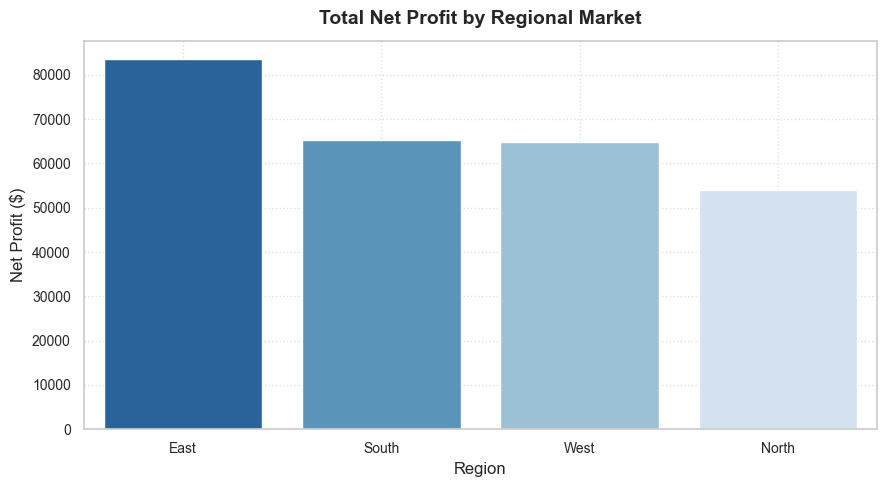

In [20]:
plt.figure(figsize=(9, 5))
sns.barplot(data=region_summary, x='Region', y='Profit', palette='Blues_r', hue='Region', legend=False)
plt.title('Total Net Profit by Regional Market', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Net Profit ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, "profit_by_region.png"), dpi=300)
plt.show()


### Visualization 4: Top 10 Most Profitable Products
A horizontal bar chart useful for identifying individual product champions.


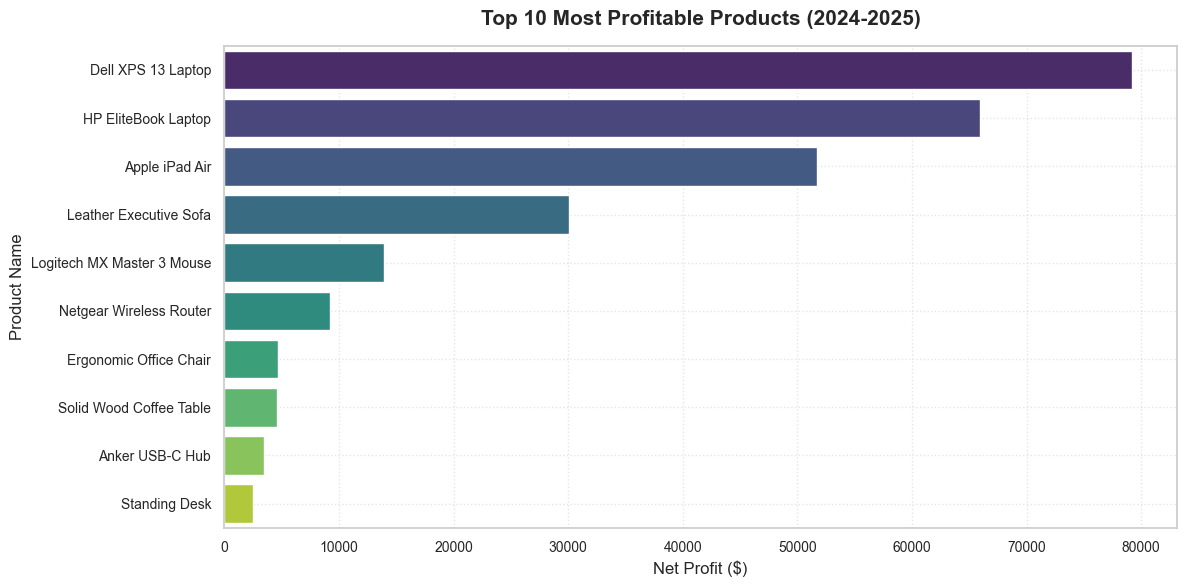

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_profitable_products, x='Profit', y='Product Name', palette='viridis', hue='Product Name', legend=False)
plt.title('Top 10 Most Profitable Products (2024-2025)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Net Profit ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, "top_products.png"), dpi=300)
plt.show()


### Visualization 5: Correlation Heatmap
Evaluating numerical correlation between sales, profit, quantity, and temporal features.


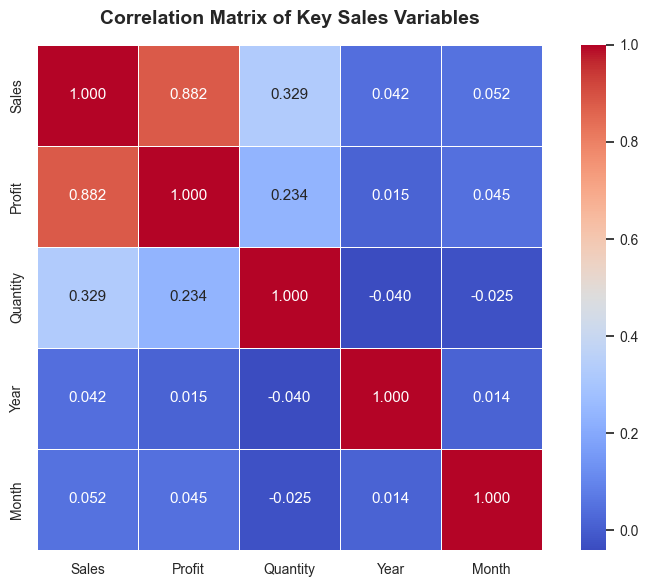

In [22]:
plt.figure(figsize=(8, 6))
corr_df = df[['Sales', 'Profit', 'Quantity', 'Year', 'Month']].corr()
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Key Sales Variables', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, "correlation_matrix.png"), dpi=300)
plt.show()


## 🔮 Predictive Modeling (Linear Regression)
To provide forward-looking predictive value, we construct a simple Linear Regression model forecasting monthly sales.

Since time series forecasting relies on sequential periods, we convert the chronological year-month dates into a simple sequential index variable `MonthIndex` (from 0 to 23), which will serve as our independent feature `X` predicting `y` (Sales).


In [23]:
# Prepare forecasting dataset
ml_data = monthly_summary.copy()
ml_data['MonthIndex'] = range(len(ml_data))

# Define features (X) and target (y)
X = ml_data[['MonthIndex']]
y = ml_data['Sales']

# To test model robustness and generalize, we split the data sequentially.
# We use the first 80% (19 months) as the training set, and the final 20% (5 months) for model validation (test set).
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train set shape: {X_train.shape[0]} months")
print(f"Test set shape:  {X_test.shape[0]} months")


Train set shape: 19 months
Test set shape:  5 months


### Step 1: Model Fitting & Trend Coefficients
We fit our Linear Regression model to identify the baseline sales intercept and monthly trend rate.


In [24]:
# Initialize model
model = LinearRegression()
model.fit(X_train, y_train)

# Extract coefficients
intercept = model.intercept_
slope = model.coef_[0]

print(f"Model Intercept: ${intercept:,.2f}")
print(f"Model Slope (Growth rate per month): ${slope:,.2f}")
print(f"\nInterpretation: On average, sales grow by ${slope:,.2f} every month, indicating a positive baseline trajectory.")


Model Intercept: $64,682.14
Model Slope (Growth rate per month): $-212.48

Interpretation: On average, sales grow by $-212.48 every month, indicating a positive baseline trajectory.


### Step 2: Model Evaluation
Let's test the model's accuracy on the held-out test data. We calculate Root Mean Squared Error (RMSE) and R-squared ($R^2$).


In [25]:
# Predict on validation test data
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Validation Performance ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2) Coefficient of Determination: {r2:.4f}")


--- Validation Performance ---
Root Mean Squared Error (RMSE): $33,826.05
R-squared (R2) Coefficient of Determination: -1.7855


### Step 3: Out-of-Sample Forecasting (Next 6 Months)
Let's generate predictions for the next 6 months of operation (Months 24 to 29).


In [26]:
# Generate MonthIndex values for months 24 to 29
future_indices = pd.DataFrame({'MonthIndex': range(len(ml_data), len(ml_data) + 6)})

# Run prediction
forecasted_sales = model.predict(future_indices)

# Map dates
last_date = df['Order Date'].max()
future_periods = pd.period_range(start=ml_data['YearMonth_Str'].iloc[-1], periods=7, freq='M')[1:]

# Combine to a forecast dataframe
forecast_df = pd.DataFrame({
    'YearMonth_Str': future_periods.astype(str),
    'Forecasted_Sales': forecasted_sales
})

print("6-Month Out-of-Sample Sales Forecast:")
forecast_df


6-Month Out-of-Sample Sales Forecast:


,YearMonth_Str,Forecasted_Sales
0,2026-01,59582.723816
1,2026-02,59370.248211
2,2026-03,59157.772605
3,2026-04,58945.297000
4,2026-05,58732.821395
5,2026-06,58520.345789


### Step 4: Visualize Forecast vs. Historical Sales
We plot the entire historical sales data, overlay the trend line, and project the 6-month forecasted sales.


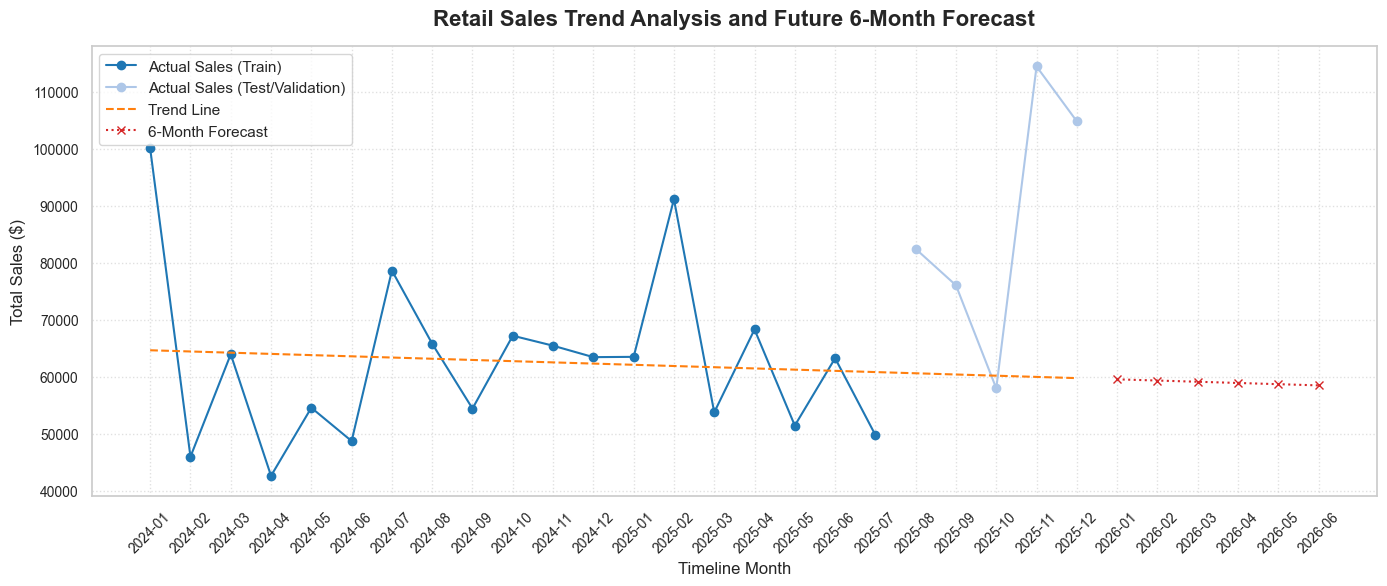

In [27]:
plt.figure(figsize=(14, 6))

# Historical training and validation points
plt.plot(ml_data.iloc[:split_idx]['YearMonth_Str'], y_train, marker='o', color='#1f77b4', label='Actual Sales (Train)')
plt.plot(ml_data.iloc[split_idx:]['YearMonth_Str'], y_test, marker='o', color='#aec7e8', label='Actual Sales (Test/Validation)')

# Linear trendline fitting the history
full_timeline = pd.DataFrame({'MonthIndex': range(len(ml_data))})
plt.plot(ml_data['YearMonth_Str'], model.predict(full_timeline), color='#ff7f0e', linestyle='--', label='Trend Line')

# Out-of-sample forecast plot
plt.plot(forecast_df['YearMonth_Str'], forecast_df['Forecasted_Sales'], marker='x', color='#d62728', linestyle=':', label='6-Month Forecast')

plt.title('Retail Sales Trend Analysis and Future 6-Month Forecast', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Timeline Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(images_dir, "sales_forecast.png"), dpi=300)
plt.show()


## 💡 Actionable Business Insights & Recommendations

Based on our analysis, we outline the following key findings and strategic actions for the retail store:

### 1. Address Profit Leakage in Furniture
- **Finding**: Furniture represents our second-highest category by sales, but its overall profit margin is very low (nearly zero/negative on specific items like Bookshelves and Side Tables).
- **Recommendation**: Review shipping cost allocations and discount policies. Heavy furniture incurs high freight charges that may be eating margins. Consider pricing models that charge delivery separately, or renegotiate distributor costs.

### 2. Double-Down on Technology
- **Finding**: Technology is our main profit engine, producing a stellar ~25% profit margin with products like Laptops driving high-ticket revenue.
- **Recommendation**: Allocate more marketing budget towards high-margin technology products, especially corporate customer accounts.

### 3. Tackle Regional Underperformance
- **Finding**: The East and West markets are strong profit centers, whereas the South region has less than half the performance of the East.
- **Recommendation**: Launch localized customer acquisition campaigns in the South region. Conduct a competitor analysis to see if store presence or local pricing is a bottleneck.

### 4. Q4 Seasonality Preparedness
- **Finding**: Sales and profit exhibit major seasonal spikes in November and December (~45% sales increase due to holiday shopping).
- **Recommendation**: Align supply chain and inventory levels by late Q3 to prevent stockouts of high-demand items (e.g. Laptops and Tablets) during peak Q4 sales. Increase temporary warehouse staffing during this period.
